In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import os
from scipy.signal import find_peaks
from numba import njit
from scipy.optimize import curve_fit

In [20]:
# Configuración para gráficos de alta calidad
plt.style.use('seaborn-v0_8-muted')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})

class AnalizadorEnvolventeEstelar:
    """
    Análisis de curvas de luz basado en la metodología de pre-blanqueo
    para detectar frecuencias principales y de la envolvente (batido).
    """
    def __init__(self, tiempo, magnitud):
        # Normalización del tiempo para mejorar la convergencia del ajuste
        self.t_base = tiempo[0]
        self.t = tiempo - self.t_base
        self.mag = magnitud
        self.residuales = magnitud.copy()
        
        self.resultados = [] # Guardará tuplas (Amplitud, Frecuencia, Fase, Offset)
        self.frecuencias = []

    @staticmethod
    def modelo_armonico(t, A, f, phi, C):
        """Modelo senoidal utilizado en el ajuste no lineal."""
        return A * np.sin(2 * np.pi * f * t + phi) + C

    def extraer_frecuencia_dominante(self, f_min=0.1, f_max=10.0):
        """Calcula el periodograma y localiza el pico de mayor potencia."""
        ls = LombScargle(self.t, self.residuales)
        freq, power = ls.autopower(minimum_frequency=f_min, maximum_frequency=f_max, samples_per_peak=15)
        
        idx_pico = np.argmax(power)
        return freq, power, freq[idx_pico]

    def ejecutar_pre_blanqueo(self, n_modos=3):
        """
        Extrae iterativamente las frecuencias principales (Pre-whitening).
        Sigue la lógica de restar la señal ajustada de los datos originales.
        """
        plt.figure(figsize=(12, 4 * n_modos))
        
        for i in range(n_modos):
            f, p, f_pico = self.extraer_frecuencia_dominante()
            
            # Estimaciones iniciales y límites (bounds) para el ajuste
            p0 = [np.std(self.residuales), f_pico, 0.0, np.mean(self.residuales)]
            bounds = ([0, f_pico - 0.05, -np.inf, -np.inf], 
                      [np.inf, f_pico + 0.05, np.inf, np.inf])

            try:
                popt, _ = curve_fit(self.modelo_armonico, self.t, self.residuales, p0=p0, bounds=bounds)
                A_opt, f_opt, phi_opt, C_opt = popt
                
                self.resultados.append(popt)
                self.frecuencias.append(f_opt)
                
                # Pre-blanqueo: Restar el modelo de los residuales actuales
                ajuste = self.modelo_armonico(self.t, *popt)
                self.residuales -= (ajuste - C_opt) # Solo restamos la oscilación

                # Visualización de cada paso del periodograma
                plt.subplot(n_modos, 1, i + 1)
                plt.plot(f, p, color='black', lw=1, label=f'Modo {i+1}')
                plt.axvline(f_opt, color='red', linestyle='--', alpha=0.6, label=f'f = {f_opt:.4f} $d^{{-1}}$')
                plt.ylabel('Potencia')
                plt.legend()
            except Exception as e:
                print(f"Error en iteración {i+1}: {e}")
                break

        plt.xlabel('Frecuencia [$d^{{-1}}$]')
        plt.tight_layout()
        plt.show()

    def analizar_envolvente(self):
        """
        Calcula la frecuencia de la envolvente a partir de las 
        frecuencias extraídas (frecuencia de batido).
        """
        if len(self.frecuencias) < 2:
            print("Se necesitan al menos 2 frecuencias para detectar una envolvente.")
            return

        # La frecuencia de la envolvente es la diferencia entre las dos principales
        f1, f2 = sorted(self.frecuencias[:2], reverse=True)
        f_env = abs(f1 - f2)
        p_env = 1 / f_env
        
        print("-" * 30)
        print(f"ANÁLISIS DE LA ENVOLVENTE")
        print(f"Frecuencia de Batido (f_env): {f_env:.5f} $d^{{-1}}$")
        print(f"Periodo de la Envolvente: {p_env:.2f} días")
        print("-" * 30)
        return f_env

    def graficar_resultado_completo(self, f_env):
        """Muestra los datos originales con la envolvente detectada."""
        plt.figure(figsize=(12, 6))
        plt.scatter(self.t + self.t_base, self.mag, s=5, color='gray', alpha=0.3, label='Datos Originales')
        
        # Reconstrucción de la señal total
        t_smooth = np.linspace(self.t.min(), self.t.max(), 2000)
        senal_total = np.zeros_like(t_smooth)
        for res in self.resultados:
            senal_total += (self.modelo_armonico(t_smooth, *res) - res[3])
        senal_total += self.resultados[0][3] # Añadir offset base

        plt.plot(t_smooth + self.t_base, senal_total, color='black', lw=1.5, label='Modelo Multi-frecuencia')
        
        plt.gca().invert_yaxis()
        plt.xlabel('Tiempo (HJD)')
        plt.ylabel('Magnitud')
        plt.title('Reconstrucción de la Curva de Luz y Variabilidad de la Envolvente')
        plt.legend()
        plt.show()


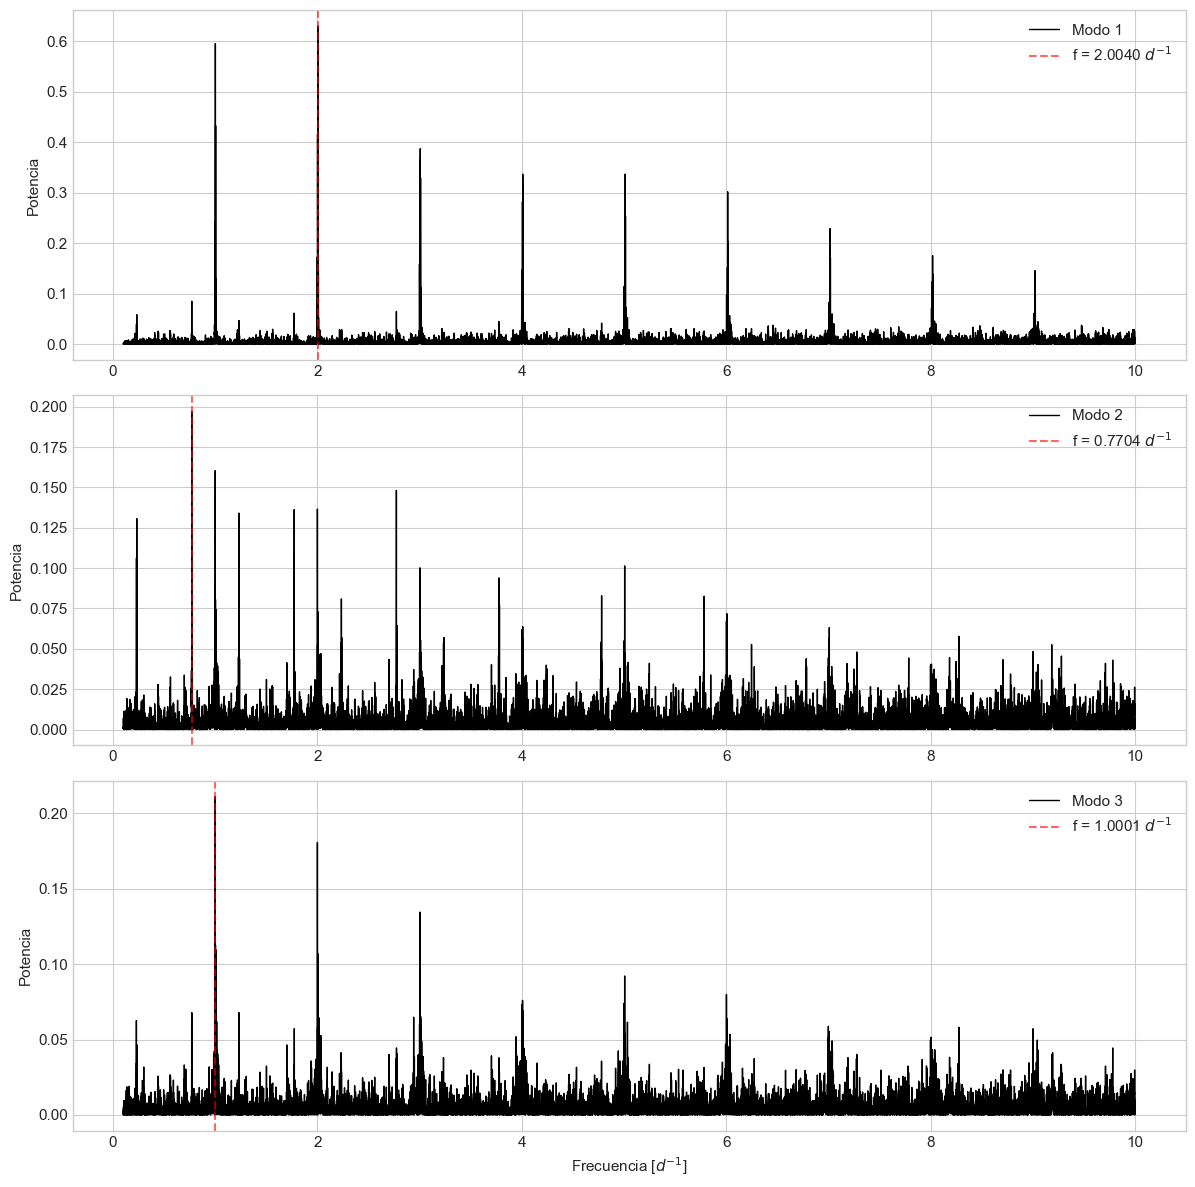

------------------------------
ANÁLISIS DE LA ENVOLVENTE
Frecuencia de Batido (f_env): 1.23354 $d^{-1}$
Periodo de la Envolvente: 0.81 días
------------------------------


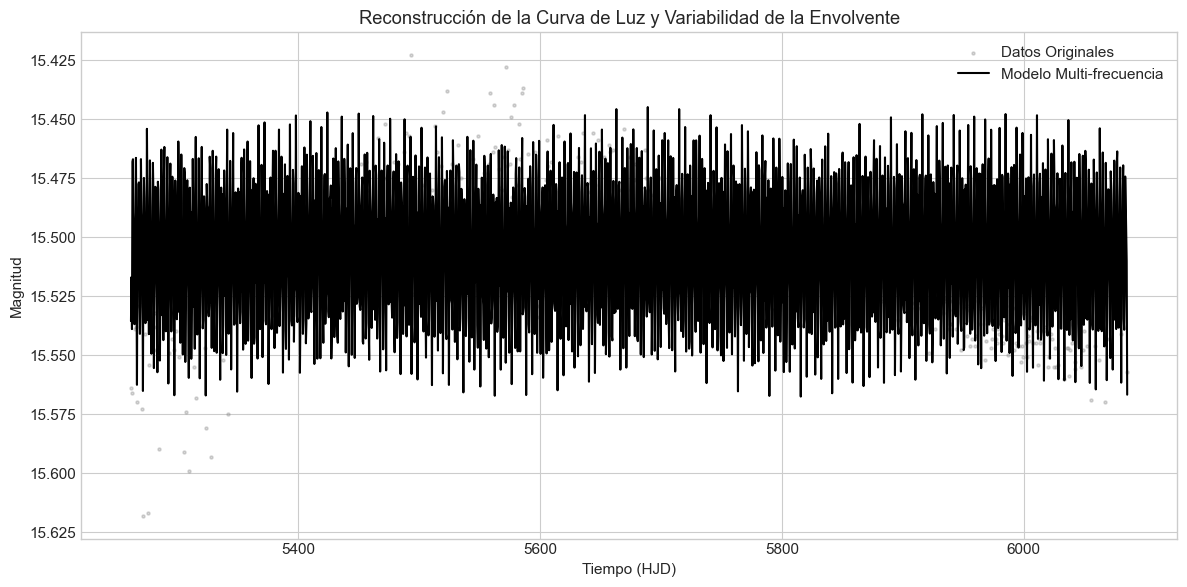

In [21]:
#LMC 562.13.11357
estrella_1 = os.path.join('Be_GSEP', 'LMC562.13.11357.dat')
df = pd.read_csv(estrella_1, sep = r"\s+", header = None)
df.columns = ['hjd', 'mag', 'err']

tiempo = df['hjd'].values
magnitud = df['mag'].values



# 2. Inicializar y procesar:
analizador = AnalizadorEnvolventeEstelar(tiempo, magnitud)
analizador.ejecutar_pre_blanqueo(n_modos=3) # Extraer 3 frecuencias principales

# 3. Obtener la frecuencia de la envolvente:
f_envolvente = analizador.analizar_envolvente()

# 4. Visualizar:
if f_envolvente:
   analizador.graficar_resultado_completo(f_envolvente)

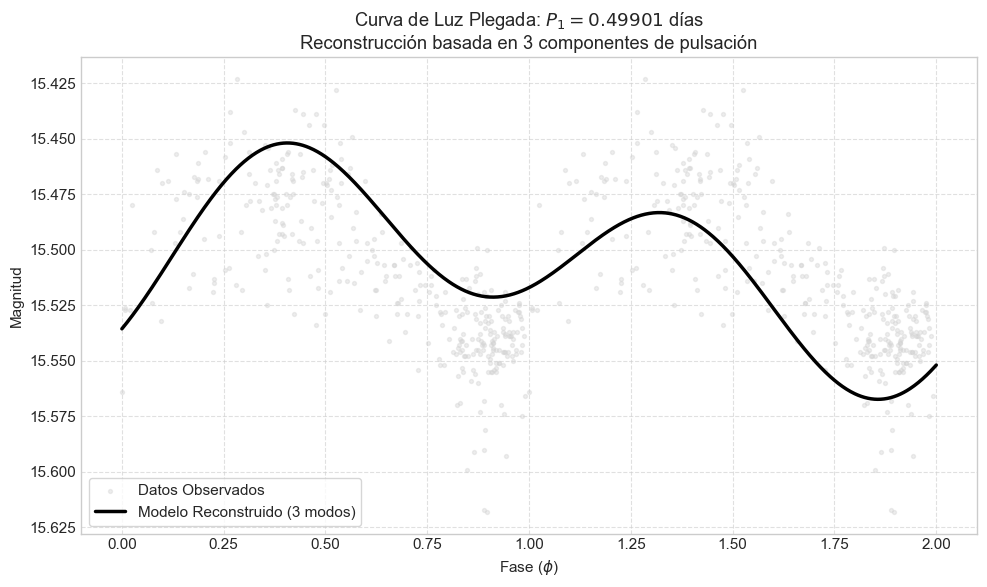

In [23]:
def graficar_curva_luz_reconstruida(analizador, n_ciclos=2):
    """
    Grafica la curva de luz plegada en fase.
    Muestra los datos originales y el modelo reconstruido (suma de todos los modos).
    """
    if not analizador.resultados:
        print("No hay modos de pulsación para reconstruir.")
        return

    # 1. Parámetros del modo principal (f1)
    A1, f1, phi1, C1 = analizador.resultados[0]
    periodo_principal = 1 / f1
    
    # 2. Plegar los datos originales
    fase_datos = (analizador.t % periodo_principal) / periodo_principal
    
    # 3. Crear una fase sintética de alta resolución para el modelo
    # Multiplicamos por n_ciclos para ver la curva repetida (estándar astronómico)
    fase_modelo = np.linspace(0, n_ciclos, 1000)
    t_modelo = fase_modelo * periodo_principal
    
    # 4. Reconstrucción multimodal: Sumamos todos los componentes detectados
    # Nota: Para que el modelo se vea 'limpio' en fase, evaluamos los modos
    # sobre un tiempo corto proporcional al periodo principal.
    mag_reconstruida = np.zeros_like(t_modelo)
    for i, res in enumerate(analizador.resultados):
        A, f, phi, C = res
        # Sumamos cada componente senoidal
        mag_reconstruida += A * np.sin(2 * np.pi * f * t_modelo + phi)
    
    # Añadimos el offset (C) del primer ajuste
    mag_reconstruida += analizador.resultados[0][3]

    # 5. Visualización
    plt.figure(figsize=(10, 6))
    
    # Graficar datos (en gris para resaltar el modelo)
    for i in range(n_ciclos):
        plt.scatter(fase_datos + i, analizador.mag, s=8, color='lightgray', 
                    alpha=0.4, label='Datos Observados' if i == 0 else "")

    # Graficar el modelo reconstruido (suma de modos)
    plt.plot(fase_modelo, mag_reconstruida, color='black', lw=2.5, 
             label=f'Modelo Reconstruido ({len(analizador.resultados)} modos)')

    # Estética profesional
    plt.gca().invert_yaxis() # Magnitudes invertidas
    plt.xlabel('Fase ($\phi$)')
    plt.ylabel('Magnitud')
    plt.title(f'Curva de Luz Plegada: $P_1 = {periodo_principal:.5f}$ días\n'
              f'Reconstrucción basada en {len(analizador.resultados)} componentes de pulsación')
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='best', frameon=True)
    plt.show()

graficar_curva_luz_reconstruida(analizador)